In [ ]:
import sys
sys.path.append("/home/kongxiangyu/yongzhang/finnal_exp")
from utils.visualizations import plot_top_down_map , images_to_video_with_audio , combine_all_audio_data
from habitat.utils.visualizations.utils import images_to_video
from PIL import Image
import pickle , os

In [28]:
path = '../dataset/pickle/v2/offline(level)/level5/D7G3Y4RVNrH/99.pkl'
with open(path , 'rb') as f:
    data = pickle.load(f)

In [22]:
print(data.keys())
print(data['obs'][0].keys())

dict_keys(['obs', 'reward', 'done', 'action_id', 'info', 'map', 'path_point', 'sound_id', 'greedy_action'])
dict_keys(['rgb', 'depth', 'spectrogram', 'angle'])


In [20]:
print(f"reward : {len(data['reward'])} , done {len(data['done'])} , obs {len(data['obs'])} , action {len(data['action_id'])}")

reward : 28 , done 28 , obs 29 , action 28


### draw depth

(-0.5, 127.5, 127.5, -0.5)

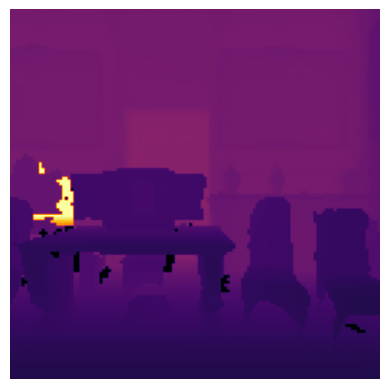

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# assume depth is your (128,128,1) array
depth_2d = np.squeeze(data['obs'][0]['depth'])  # becomes (128,128)

plt.imshow(depth_2d, cmap='inferno')
plt.axis('off')


### draw obs

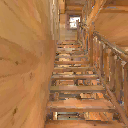

In [10]:
Image.fromarray(data['obs'][0]['rgb'])

### draw map

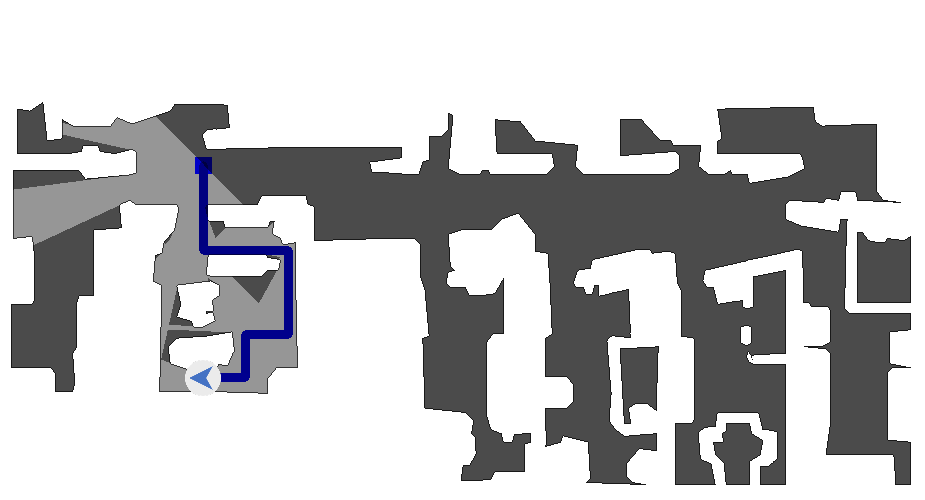

In [14]:
Image.fromarray(plot_top_down_map(data['info'][17]))

### draw video

In [29]:
img = []
for i in data['info']:
    img.append(np.array(Image.fromarray(plot_top_down_map(i))))
images_to_video(images=img , output_dir='./' , video_name='test' , fps=1)

2025-10-29 11:08:05,078 Video created: ./test.mp4
100%|██████████| 15/15 [00:00<00:00, 345.29it/s]


### draw audio

In [22]:
combine_all_audio_data(data)

开始处理 14 个音频片段...
片段 0: 有声音 (最大值: 1.82e-01)
片段 1: 有声音 (最大值: 2.68e-01)
片段 2: 有声音 (最大值: 1.89e-01)
片段 3: 有声音 (最大值: 1.76e-01)
片段 4: 有声音 (最大值: 2.37e-01)
片段 5: 有声音 (最大值: 1.78e-01)
片段 6: 有声音 (最大值: 1.86e-01)
片段 7: 有声音 (最大值: 2.62e-01)
片段 8: 有声音 (最大值: 3.01e-01)
片段 9: 有声音 (最大值: 4.04e-01)
片段 10: 有声音 (最大值: 4.39e-01)
片段 11: 有声音 (最大值: 2.85e-01)
片段 12: 有声音 (最大值: 1.44e+00)
片段 13: 有声音 (最大值: 1.44e+00)
正在合并音频片段...
✅ 所有音频已合并保存至：combined_audio.wav
合并后音频形状：(224000, 2)
总时长：14.00 秒


In [30]:
data['greedy_action']

[[3, 1, 3, 1, 1, 3, 1, 1, 0], [3, 1, 1, 0], [3, 3, 1, 0]]

In [31]:
data['action_id']

[3, 1, 3, 1, 1, 3, 2, 3, 1, 1, 1, 3, 3, 1, 0]